In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

In [3]:
df = pd.read_csv("C:\\Users\\Dell\\Downloads\\22. messy_sales_data.csv")

In [4]:
df

,OrderID,CustomerID,CustomerName,City,Category,PaymentMode,Price,Quantity,DiscountPct,Rating,OrderDate,CustomerAge,Email,Phone,ReviewText
0,ORD51058,CUST04879,Chaitanya Mane,bangalore,Grocery,net_banking,904.48,3.0,10,3.3,2023-04-24,29.0,chaitanya.mane@gmail.com,9454663439,Packaging was bad
1,ORD70248,CUST00177,Siddharth Sha,DELHI,SPORTS,Net Banking,1823.76,4.0,20,5.0,04-01-2023,38.0,NaN,NaN,great service
2,ORD43804,CUST04537,Nathaniel Chatterjee,chennai,electronic,Upi,770.67,1.0,0,4.9,11/17/2024,40.0,nathaniel.chatterjee@outlook.com,9573975601,Okayish product
3,ORD46367,CUST07605,pranit contractor,Jaipur,Clothing,COD,2028.06,1.0,0,2.9,NaN,41.0,pranit.contractor@rediffmail.com,9235766629,NaN
4,ORD32922,CUST03180,Hemang Chakraborty,Amdavad,FURNITURE,cc,604.00,4.0,10,3.7,14 Jan 2023,44.0,hemang.chakraborty@outlook.com,9731250657,Superb!!! fast delivery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106570,ORD49057,CUST01636,MAX OM,chennai,FURNITURE,debit card,Rs.1961.37,4.0,0,5.0,2023-06-11,32.0,max.om@outlook.com,9123457578,Amazing quality!!!
106571,ORD60012,CUST01826,CHARAN MANNE,pune,Toys,Cash on Delivery,Rs.1468.22,2.0,20,3.3,22 Apr 2024,43.0,charan.manne@yahoo.com,9226831132,Good product loved it
106572,ORD78050,CUST04033,Isaiah Wali,DELHI,Furniture,Debit Card,414.94,2.0,10,3.3,11/09/2024,23.0,isaiah.wali@hotmail.com,9758098090,Not satisfied poor quality
106573,ORD68225,CUST04602,Ladli Nazareth,AHMEDABAD,electronic,DEBIT CARD,916.52,1.0,25,4.6,19/12/2024,50.0,NaN,9914721436,NaN


In [5]:
df.City

0         bangalore
1             DELHI
2           chennai
3           Jaipur 
4           Amdavad
            ...    
106570      chennai
106571         pune
106572        DELHI
106573    AHMEDABAD
106574      Chennai
Name: City, Length: 106575, dtype: object

In [6]:
df.PaymentMode

0              net_banking
1              Net Banking
2                      Upi
3                      COD
4                       cc
                ...       
106570          debit card
106571    Cash on Delivery
106572          Debit Card
106573          DEBIT CARD
106574          DEBIT CARD
Name: PaymentMode, Length: 106575, dtype: object

In [7]:
df['City'] = df['City'].fillna("Unknown")
df["PaymentMode"] = df["PaymentMode"].fillna(df["PaymentMode"].mode()[0])

In [8]:
df.City

0         bangalore
1             DELHI
2           chennai
3           Jaipur 
4           Amdavad
            ...    
106570      chennai
106571         pune
106572        DELHI
106573    AHMEDABAD
106574      Chennai
Name: City, Length: 106575, dtype: object

In [9]:
df.PaymentMode

0              net_banking
1              Net Banking
2                      Upi
3                      COD
4                       cc
                ...       
106570          debit card
106571    Cash on Delivery
106572          Debit Card
106573          DEBIT CARD
106574          DEBIT CARD
Name: PaymentMode, Length: 106575, dtype: object

In [10]:
df.OrderID

0         ORD51058
1         ORD70248
2         ORD43804
3         ORD46367
4         ORD32922
            ...   
106570    ORD49057
106571    ORD60012
106572    ORD78050
106573    ORD68225
106574    ORD72531
Name: OrderID, Length: 106575, dtype: object

In [11]:
df = df.drop_duplicates()
dup_mask = df['OrderID'].duplicated(keep='first')
df.loc[dup_mask, 'OrderID'] = df.loc[dup_mask, 'OrderID'] + '_DUP' + df.loc[dup_mask].groupby('OrderID').cumcount().astype(str)

In [12]:
df.OrderID

0         ORD51058
1         ORD70248
2         ORD43804
3         ORD46367
4         ORD32922
            ...   
106570    ORD49057
106571    ORD60012
106572    ORD78050
106573    ORD68225
106574    ORD72531
Name: OrderID, Length: 105519, dtype: object

In [13]:
df['CustomerName']

0               Chaitanya Mane
1                Siddharth Sha
2         Nathaniel Chatterjee
3            pranit contractor
4           Hemang Chakraborty
                  ...         
106570                MAX OM  
106571            CHARAN MANNE
106572             Isaiah Wali
106573        Ladli Nazareth  
106574               Yatin Rao
Name: CustomerName, Length: 105519, dtype: object

In [14]:
df['CustomerName'] = df['CustomerName'].str.strip().str.title()

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\4292935889.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CustomerName'] = df['CustomerName'].str.strip().str.title()


In [15]:
df['CustomerName']

0               Chaitanya Mane
1                Siddharth Sha
2         Nathaniel Chatterjee
3            Pranit Contractor
4           Hemang Chakraborty
                  ...         
106570                  Max Om
106571            Charan Manne
106572             Isaiah Wali
106573          Ladli Nazareth
106574               Yatin Rao
Name: CustomerName, Length: 105519, dtype: object

In [16]:
df['City'] = df['City'].str.strip().str.lower()

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\357960059.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City'] = df['City'].str.strip().str.lower()


In [17]:
df['City']

0         bangalore
1             delhi
2           chennai
3            jaipur
4           amdavad
            ...    
106570      chennai
106571         pune
106572        delhi
106573    ahmedabad
106574      chennai
Name: City, Length: 105519, dtype: object

In [18]:
city_map = {
    'mumbai': 'Mumbai', 'bombay': 'Mumbai',
    'delhi': 'Delhi', 'new delhi': 'Delhi',
    'bangalore': 'Bangalore', 'bengaluru': 'Bangalore', 'banglore': 'Bangalore',
    'chennai': 'Chennai', 'madras': 'Chennai',
    'kolkata': 'Kolkata', 'calcutta': 'Kolkata',
    'hyderabad': 'Hyderabad',
    'pune': 'Pune', 'poona': 'Pune',
    'ahmedabad': 'Ahmedabad', 'amdavad': 'Ahmedabad',
    'jaipur': 'Jaipur',
    'lucknow': 'Lucknow',
    'unknown': 'Unknown'
}

In [19]:
df['City']

0         bangalore
1             delhi
2           chennai
3            jaipur
4           amdavad
            ...    
106570      chennai
106571         pune
106572        delhi
106573    ahmedabad
106574      chennai
Name: City, Length: 105519, dtype: object

In [20]:
df['City'] = df['City'].map(city_map).fillna(df['City'].str.title())

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\3324096277.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['City'] = df['City'].map(city_map).fillna(df['City'].str.title())


In [21]:
df['City'] 

0         Bangalore
1             Delhi
2           Chennai
3            Jaipur
4         Ahmedabad
            ...    
106570      Chennai
106571         Pune
106572        Delhi
106573    Ahmedabad
106574      Chennai
Name: City, Length: 105519, dtype: object

In [22]:
df['Category'] 

0            Grocery
1             SPORTS
2         electronic
3           Clothing
4          FURNITURE
             ...    
106570     FURNITURE
106571          Toys
106572     Furniture
106573    electronic
106574         Sport
Name: Category, Length: 105519, dtype: object

In [23]:
df['Category'] = df['Category'].str.strip().str.lower().str.rstrip('s')
df['Category'] = df['Category'].replace({'electronic': 'electronics'}).replace({"Grocery":"Grocerie"})
df['Category'] = df['Category'].str.title()

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\851889051.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Category'] = df['Category'].str.strip().str.lower().str.rstrip('s')
C:\Users\Dell\AppData\Local\Temp\ipykernel_688\851889051.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Category'] = df['Category'].replace({'electronic': 'electronics'}).replace({"Grocery":"Grocerie"})
C:\Users\Dell\AppData\Local\Temp\ipykernel_688\851889051.py:3: SettingWithCopyWarning: 
A value is trying to be set on 

In [24]:
df['Category']

0             Grocery
1               Sport
2         Electronics
3            Clothing
4           Furniture
             ...     
106570      Furniture
106571            Toy
106572      Furniture
106573    Electronics
106574          Sport
Name: Category, Length: 105519, dtype: object

In [25]:
df.PaymentMode

0              net_banking
1              Net Banking
2                      Upi
3                      COD
4                       cc
                ...       
106570          debit card
106571    Cash on Delivery
106572          Debit Card
106573          DEBIT CARD
106574          DEBIT CARD
Name: PaymentMode, Length: 105519, dtype: object

In [26]:
payment_map = {
    'credit card': 'Credit Card', 'cc': 'Credit Card', 'credit_card': 'Credit Card',
    'debit card': 'Debit Card', 'dc': 'Debit Card',
    'upi': 'UPI',
    'cod': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery',
    'net banking': 'Net Banking', 'netbanking': 'Net Banking', 'net_banking': 'Net Banking'
}

In [27]:
df.PaymentMode

0              net_banking
1              Net Banking
2                      Upi
3                      COD
4                       cc
                ...       
106570          debit card
106571    Cash on Delivery
106572          Debit Card
106573          DEBIT CARD
106574          DEBIT CARD
Name: PaymentMode, Length: 105519, dtype: object

In [28]:
df['PaymentMode'] = df['PaymentMode'].str.strip().str.lower().map(payment_map)

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\3387875625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['PaymentMode'] = df['PaymentMode'].str.strip().str.lower().map(payment_map)


In [29]:
df['PaymentMode']

0              Net Banking
1              Net Banking
2                      UPI
3         Cash on Delivery
4              Credit Card
                ...       
106570          Debit Card
106571    Cash on Delivery
106572          Debit Card
106573          Debit Card
106574          Debit Card
Name: PaymentMode, Length: 105519, dtype: object

In [30]:
df['Price']

0             904.48
1            1823.76
2             770.67
3            2028.06
4             604.00
             ...    
106570    Rs.1961.37
106571    Rs.1468.22
106572        414.94
106573        916.52
106574        891.46
Name: Price, Length: 105519, dtype: object

In [31]:
df['Price'] = df['Price'].astype(str).str.replace(r'[₹,]', '', regex=True).str.replace('Rs.', '', regex=False).str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').abs()

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\1382675713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = df['Price'].astype(str).str.replace(r'[₹,]', '', regex=True).str.replace('Rs.', '', regex=False).str.strip()
C:\Users\Dell\AppData\Local\Temp\ipykernel_688\1382675713.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = pd.to_numeric(df['Price'], errors='coerce').abs()


In [32]:
df['Price']

0          904.48
1         1823.76
2          770.67
3         2028.06
4          604.00
           ...   
106570    1961.37
106571    1468.22
106572     414.94
106573     916.52
106574     891.46
Name: Price, Length: 105519, dtype: float64

In [33]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').abs()

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\829960451.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').abs()


In [34]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df.loc[(df['Rating'] < 0) | (df['Rating'] > 5), 'Rating'] = np.nan

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\3997167636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')


In [35]:
df['CustomerAge'] = pd.to_numeric(df['CustomerAge'], errors='coerce')
df.loc[(df['CustomerAge'] < 10) | (df['CustomerAge'] > 100), 'CustomerAge'] = np.nan

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\24729819.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CustomerAge'] = pd.to_numeric(df['CustomerAge'], errors='coerce')


In [36]:
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median()).astype(int)
df['Rating'] = df['Rating'].fillna(df.groupby('Category')['Rating'].transform('mean'))
df['CustomerAge'] = df['CustomerAge'].fillna(df['CustomerAge'].median()).astype(int)

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\1636431505.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Price'] = df['Price'].fillna(df['Price'].median())
C:\Users\Dell\AppData\Local\Temp\ipykernel_688\1636431505.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median()).astype(int)
C:\Users\Dell\AppData\Local\Temp\ipykernel_688\1636431505.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

In [37]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce', dayfirst=True)
df['OrderDate'] = df['OrderDate'].fillna(df['OrderDate'].median())

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\4094877240.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce', dayfirst=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_688\4094877240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce', dayfirst=True)
C:\Users\Dell\AppData\Local\Temp\ipykernel_688\4094877240.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyd

In [38]:
df = df.rename(columns={
    'OrderID': 'order_id', 'CustomerID': 'customer_id', 'CustomerName': 'customer_name',
    'City': 'city', 'Category': 'category', 'PaymentMode': 'payment_mode',
    'Price': 'price', 'Quantity': 'quantity', 'DiscountPct': 'discount_pct',
    'Rating': 'rating', 'OrderDate': 'order_date', 'CustomerAge': 'customer_age',
    'Email': 'email', 'Phone': 'phone', 'ReviewText': 'review_text'
})

In [39]:
df['total_price'] = (df['price'] * df['quantity']).round(2)
df['discount_amount'] = (df['total_price'] * df['discount_pct'] / 100).round(2)
df['final_price'] = (df['total_price'] - df['discount_amount']).round(2)

df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
df['order_weekday'] = df['order_date'].dt.day_name()

bins = [0, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels)

print("Cleaned data shape:", df.shape)
df.head()

Cleaned data shape: (105519, 23)


,order_id,customer_id,customer_name,city,category,payment_mode,price,quantity,discount_pct,rating,...,phone,review_text,total_price,discount_amount,final_price,order_year,order_month,order_month_name,order_weekday,age_group
0,ORD51058,CUST04879,Chaitanya Mane,Bangalore,Grocery,Net Banking,904.48,3,10,3.3,...,9454663439,Packaging was bad,2713.44,271.34,2442.10,2023,4,April,Monday,26-35
1,ORD70248,CUST00177,Siddharth Sha,Delhi,Sport,Net Banking,1823.76,4,20,5.0,...,NaN,great service,7295.04,1459.01,5836.03,2024,1,January,Tuesday,36-50
2,ORD43804,CUST04537,Nathaniel Chatterjee,Chennai,Electronics,UPI,770.67,1,0,4.9,...,9573975601,Okayish product,770.67,0.00,770.67,2024,1,January,Tuesday,36-50
3,ORD46367,CUST07605,Pranit Contractor,Jaipur,Clothing,Cash on Delivery,2028.06,1,0,2.9,...,9235766629,NaN,2028.06,0.00,2028.06,2024,1,January,Tuesday,36-50
4,ORD32922,CUST03180,Hemang Chakraborty,Ahmedabad,Furniture,Credit Card,604.00,4,10,3.7,...,9731250657,Superb!!! fast delivery,2416.00,241.60,2174.40,2024,1,January,Tuesday,36-50


In [40]:
df

,order_id,customer_id,customer_name,city,category,payment_mode,price,quantity,discount_pct,rating,...,phone,review_text,total_price,discount_amount,final_price,order_year,order_month,order_month_name,order_weekday,age_group
0,ORD51058,CUST04879,Chaitanya Mane,Bangalore,Grocery,Net Banking,904.48,3,10,3.3,...,9454663439,Packaging was bad,2713.44,271.34,2442.10,2023,4,April,Monday,26-35
1,ORD70248,CUST00177,Siddharth Sha,Delhi,Sport,Net Banking,1823.76,4,20,5.0,...,NaN,great service,7295.04,1459.01,5836.03,2024,1,January,Tuesday,36-50
2,ORD43804,CUST04537,Nathaniel Chatterjee,Chennai,Electronics,UPI,770.67,1,0,4.9,...,9573975601,Okayish product,770.67,0.00,770.67,2024,1,January,Tuesday,36-50
3,ORD46367,CUST07605,Pranit Contractor,Jaipur,Clothing,Cash on Delivery,2028.06,1,0,2.9,...,9235766629,NaN,2028.06,0.00,2028.06,2024,1,January,Tuesday,36-50
4,ORD32922,CUST03180,Hemang Chakraborty,Ahmedabad,Furniture,Credit Card,604.00,4,10,3.7,...,9731250657,Superb!!! fast delivery,2416.00,241.60,2174.40,2024,1,January,Tuesday,36-50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106570,ORD49057,CUST01636,Max Om,Chennai,Furniture,Debit Card,1961.37,4,0,5.0,...,9123457578,Amazing quality!!!,7845.48,0.00,7845.48,2023,6,June,Sunday,26-35
106571,ORD60012,CUST01826,Charan Manne,Pune,Toy,Cash on Delivery,1468.22,2,20,3.3,...,9226831132,Good product loved it,2936.44,587.29,2349.15,2024,1,January,Tuesday,36-50
106572,ORD78050,CUST04033,Isaiah Wali,Delhi,Furniture,Debit Card,414.94,2,10,3.3,...,9758098090,Not satisfied poor quality,829.88,82.99,746.89,2024,1,January,Tuesday,18-25
106573,ORD68225,CUST04602,Ladli Nazareth,Ahmedabad,Electronics,Debit Card,916.52,1,25,4.6,...,9914721436,NaN,916.52,229.13,687.39,2024,1,January,Tuesday,36-50


In [41]:
df.columns

Index(['order_id', 'customer_id', 'customer_name', 'city', 'category',
       'payment_mode', 'price', 'quantity', 'discount_pct', 'rating',
       'order_date', 'customer_age', 'email', 'phone', 'review_text',
       'total_price', 'discount_amount', 'final_price', 'order_year',
       'order_month', 'order_month_name', 'order_weekday', 'age_group'],
      dtype='object')

# 3. Bivariate Analysis
Bivariate analysis looks at the relationship between two variables — for example, how price varies across categories, or how rating relates to revenue.

### 3.1 Category vs Final Price — Boxplot

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\946014676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='final_price', palette='Set2')


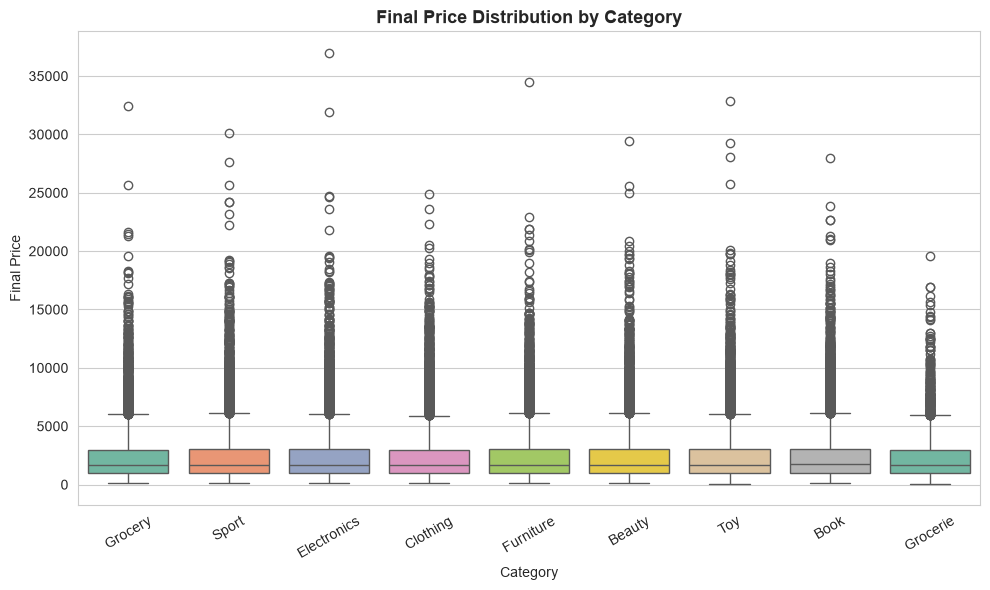

In [42]:
# A boxplot shows the spread and outliers of final_price within each category,
# helping us compare price ranges across categories at a glance
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='final_price', palette='Set2')
plt.title('Final Price Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Final Price')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.2 City vs Total Revenue — Bar Chart

In [43]:
df.groupby('city')['price'].mean()

city
Ahmedabad    1194.147951
Bangalore    1189.181721
Chennai      1195.016112
Delhi        1192.988212
Hyderabad    1187.616269
Jaipur       1176.814163
Kolkata      1200.202351
Lucknow      1178.428834
Mumbai       1175.537423
Pune         1201.821645
Unknown      1196.151889
Name: price, dtype: float64

In [44]:
df.groupby("city")["final_price"].sum()

city
Ahmedabad    24468254.09
Bangalore    24513890.90
Chennai      24968286.44
Delhi        24185276.80
Hyderabad    24475460.12
Jaipur       24266217.92
Kolkata      24898609.55
Lucknow      24000182.34
Mumbai       24733651.80
Pune         24404213.09
Unknown       4819831.99
Name: final_price, dtype: float64

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\3450925081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='flare')


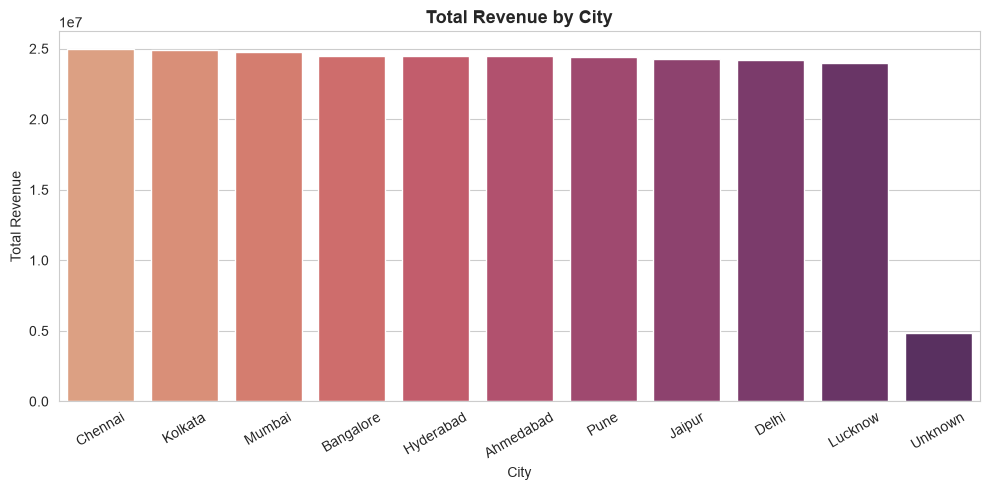

In [46]:
# Total revenue generated by each city, sorted for easy comparison
city_revenue = df.groupby('city')['final_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='flare')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.3 Payment Mode vs Average Order Value — Bar Chart

In [47]:
# Does the payment method used relate to how much customers typically spend?
avg_order_by_payment = df.groupby('payment_mode')['final_price'].mean().sort_values(ascending=False)

In [48]:
avg_order_by_payment

payment_mode
Debit Card          2382.300805
UPI                 2380.769155
Credit Card         2367.335074
Net Banking         2352.791658
Cash on Delivery    2348.222571
Name: final_price, dtype: float64

C:\Users\Dell\AppData\Local\Temp\ipykernel_688\341371632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_order_by_payment.index, y=avg_order_by_payment.values, palette='rocket')


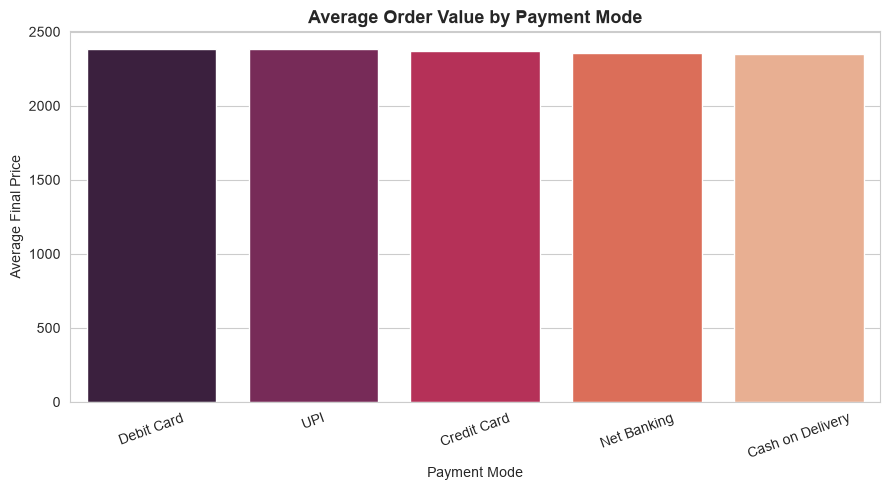

In [49]:
plt.figure(figsize=(9, 5))
sns.barplot(x=avg_order_by_payment.index, y=avg_order_by_payment.values, palette='rocket')
plt.title('Average Order Value by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Average Final Price')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 3.4 Monthly Revenue Trend — Line Chart

In [51]:
monthly_revenue = df.groupby(['order_year', 'order_month'])['final_price'].sum().reset_index()

In [52]:
monthly_revenue

,order_year,order_month,final_price
0,2023,1,2.092637e+06
1,2023,2,1.648678e+06
2,2023,3,2.155350e+06
3,2023,4,1.969884e+06
4,2023,5,1.932309e+06
5,2023,6,1.970155e+06
6,2023,7,2.255457e+06
7,2023,8,1.984711e+06
8,2023,9,2.068556e+06
9,2023,10,2.000655e+06


In [53]:
# A line chart is the clearest way to see revenue trend over time (month by month)
monthly_revenue = df.groupby(['order_year', 'order_month'])['final_price'].sum().reset_index()
monthly_revenue['period'] = (monthly_revenue['order_year'].astype(str) + '-' +
                              monthly_revenue['order_month'].astype(str).str.zfill(2))
monthly_revenue = monthly_revenue.sort_values('period')

In [54]:
monthly_revenue

,order_year,order_month,final_price,period
0,2023,1,2.092637e+06,2023-01
1,2023,2,1.648678e+06,2023-02
2,2023,3,2.155350e+06,2023-03
3,2023,4,1.969884e+06,2023-04
4,2023,5,1.932309e+06,2023-05
5,2023,6,1.970155e+06,2023-06
6,2023,7,2.255457e+06,2023-07
7,2023,8,1.984711e+06,2023-08
8,2023,9,2.068556e+06,2023-09
9,2023,10,2.000655e+06,2023-10


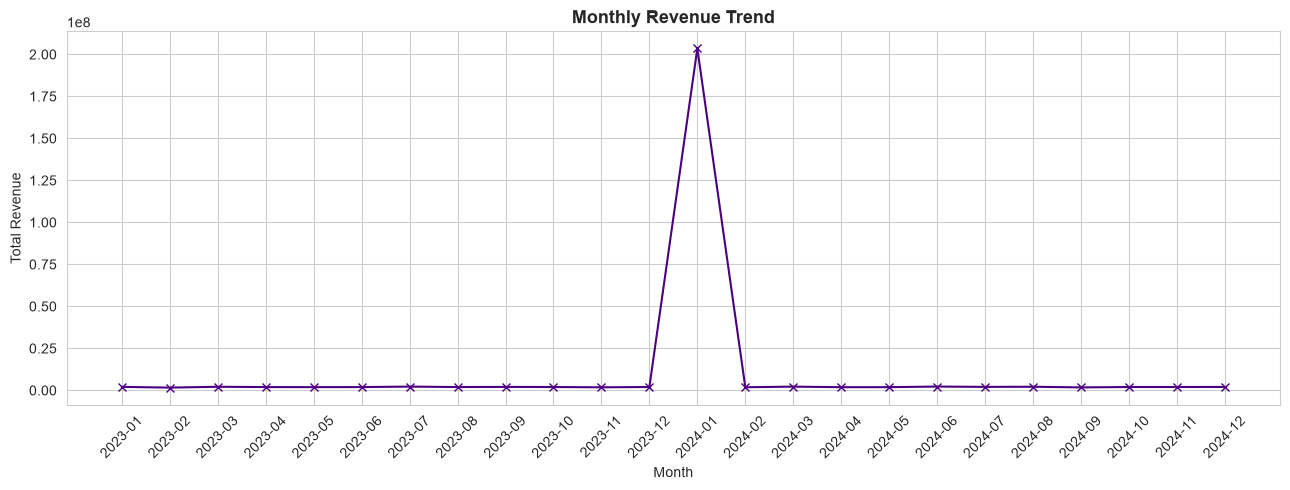

In [55]:
plt.figure(figsize=(13, 5))
plt.plot(monthly_revenue['period'], monthly_revenue['final_price'], marker='x', color='indigo')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
df.groupby(["city", "payment_mode"])["quantity"].sum()

city       payment_mode    
Ahmedabad  Cash on Delivery    4368
           Credit Card         4452
           Debit Card          4339
           Net Banking         4357
           UPI                 5054
Bangalore  Cash on Delivery    4420
           Credit Card         4316
           Debit Card          4387
           Net Banking         4599
           UPI                 5187
Chennai    Cash on Delivery    4353
           Credit Card         4529
           Debit Card          4602
           Net Banking         4452
           UPI                 5176
Delhi      Cash on Delivery    4282
           Credit Card         4273
           Debit Card          4501
           Net Banking         4427
           UPI                 4936
Hyderabad  Cash on Delivery    4388
           Credit Card         4306
           Debit Card          4509
           Net Banking         4665
           UPI                 4903
Jaipur     Cash on Delivery    4406
           Credit Card         4271


In [57]:
df.columns

Index(['order_id', 'customer_id', 'customer_name', 'city', 'category',
       'payment_mode', 'price', 'quantity', 'discount_pct', 'rating',
       'order_date', 'customer_age', 'email', 'phone', 'review_text',
       'total_price', 'discount_amount', 'final_price', 'order_year',
       'order_month', 'order_month_name', 'order_weekday', 'age_group'],
      dtype='object')

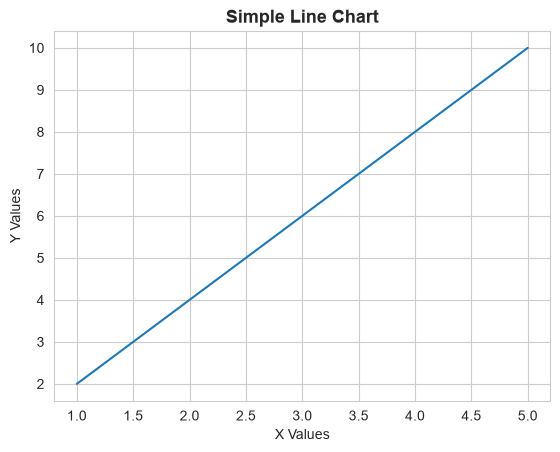

In [58]:
x = [1, 2, 3, 4, 5]                 # Independent variable (e.g., days, hours)
y = [2, 4, 6, 8, 10]                # Dependent variable (e.g., sales, growth)

plt.plot(x, y)                      # Plots a line connecting (x, y) pairs
plt.title("Simple Line Chart")      # Chart title (makes chart readable)
plt.xlabel("X Values")              # Label for X-axis
plt.ylabel("Y Values")              # Label for Y-axis
plt.show()    

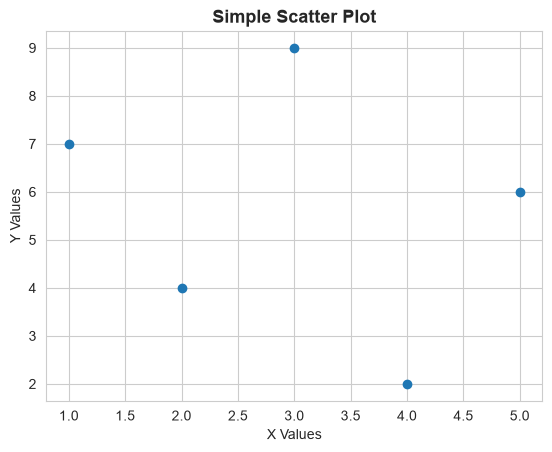

In [59]:
x = [1, 2, 3, 4, 5]                 # X: First variable (e.g., test score)
y = [7, 4, 9, 2, 6]                 # Y: Second variable (e.g., hours studied)

plt.scatter(x, y)                   # Shows each (x, y) as a dot (no line)
plt.title("Simple Scatter Plot")
plt.xlabel("X Values")
plt.ylabel("Y Values")
plt.show()